# Build All-Metrics Correlation Dataframe (Radius = 100/100)

This notebook:
1. Loads **all available metrics** from pickle files, filtering to `radius_pre = 100` and `radius_post = 100` only
2. For each participant × session combination, computes the **Pearson correlation** between `metric_pre` and `metric_post` **across trials** for every (pre-metric, post-metric) pair
3. Attaches stimulated-network labels
4. Saves the resulting correlation dataframes for both **iEEG (SEEG)** and **hdEEG**

Output columns: `Participant, Session, Radius_pre, Radius_post, Metric_pre, Metric_post, Correlation, p_value, Network`

**Note:** p-values use the t-distribution with `n_trials − 2` degrees of freedom. Trials with NaN in any metric within a group are excluded listwise (all metrics share the same trial set after dropping NaN rows).

In [1]:
from __future__ import annotations

import pickle
import re
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import t as scipy_t

warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
RS_PRE_ALLOWED  = {100}
RS_POST_ALLOWED = {100}

# Expected filename: e.g. sub-01_run-03_100_100_metrics.pkl
FILENAME_RE = re.compile(r'(sub-\d+)_run-(\d+)_(\d+)_(\d+)_metrics\.pkl$')


def resolve_project_root() -> Path:
    """Resolve project root whether notebook is run from repo root or /notebooks."""
    cwd = Path.cwd().resolve()
    if (cwd / 'data').exists():
        return cwd
    if (cwd.parent / 'data').exists():
        return cwd.parent
    raise FileNotFoundError('Could not find project root containing data/.')


def normalize_metric_value(value):
    """Convert metric values to scalar Python types."""
    if isinstance(value, np.ndarray):
        return value.item() if value.size == 1 else value.tolist()
    if isinstance(value, (list, tuple)):
        return value[0] if len(value) == 1 else list(value)
    return value


def normalize_code(value: str, new_prefix: str) -> str:
    match = re.search(r'(\d+)$', str(value))
    if not match:
        raise ValueError(f'Could not normalize code: {value}')
    return f'{new_prefix}{int(match.group(1))}'

In [3]:
def parse_file_all_metrics(data: dict, file_path: Path, records_map: dict):
    """Parse one pickle file and populate records_map with ALL available metrics.
    Only files matching radius_pre=100 and radius_post=100 are processed.
    """
    filename_match = FILENAME_RE.search(file_path.name)
    if not filename_match:
        return

    sub_id   = filename_match.group(1)
    run_id   = f"run-{int(filename_match.group(2)):02d}"
    rpre_int = int(filename_match.group(3))
    rpost_int = int(filename_match.group(4))

    if rpre_int not in RS_PRE_ALLOWED or rpost_int not in RS_POST_ALLOWED:
        return
    if not isinstance(data, dict):
        return

    pre_root  = data.get('metrics_pre',  {})
    post_root = data.get('metrics_post', {})
    if not isinstance(pre_root,  dict): pre_root  = {}
    if not isinstance(post_root, dict): post_root = {}

    all_metric_names = set(pre_root.keys()) | set(post_root.keys())

    for metric_name in all_metric_names:
        pre_trials  = pre_root.get(metric_name,  {})
        post_trials = post_root.get(metric_name, {})

        trial_ids = set()
        if isinstance(pre_trials,  dict): trial_ids.update(pre_trials.keys())
        if isinstance(post_trials, dict): trial_ids.update(post_trials.keys())

        for trial in trial_ids:
            try:
                trial_id = int(trial)
            except Exception:
                trial_id = trial

            key = (sub_id, rpre_int, rpost_int, run_id, trial_id, metric_name)
            rec = records_map[key]
            rec.update({
                'sub': sub_id, 'radius_pre': rpre_int, 'radius_post': rpost_int,
                'run_is': run_id, 'trial_id': trial_id, 'metric_name': metric_name,
            })
            if isinstance(pre_trials,  dict) and trial in pre_trials:
                rec['metric_value_pre']  = normalize_metric_value(pre_trials[trial])
            if isinstance(post_trials, dict) and trial in post_trials:
                rec['metric_value_post'] = normalize_metric_value(post_trials[trial])

In [4]:
def compute_pearson_matrix(pre_wide: pd.DataFrame, post_wide: pd.DataFrame):
    """Vectorized Pearson r and p-values for all (pre_metric × post_metric) pairs.

    Uses listwise deletion: trials with NaN in *any* column of either
    pre_wide or post_wide are dropped before computing correlations.

    Returns
    -------
    r      : ndarray (n_pre, n_post)
    p_vals : ndarray (n_pre, n_post)
    n      : int  — number of trials used
    """
    common_idx = pre_wide.index.intersection(post_wide.index)
    combined   = pd.concat(
        [pre_wide.loc[common_idx], post_wide.loc[common_idx]], axis=1
    ).dropna()

    pre_cols  = pre_wide.columns.tolist()
    post_cols = post_wide.columns.tolist()
    n         = len(combined)

    shape = (len(pre_cols), len(post_cols))
    if n < 2:
        return np.full(shape, np.nan), np.full(shape, np.nan), n

    X = combined[pre_cols].values.astype(float)   # (n, n_pre)
    Y = combined[post_cols].values.astype(float)  # (n, n_post)

    # Center
    Xc = X - X.mean(axis=0)
    Yc = Y - Y.mean(axis=0)

    # Sum of squares
    sx = np.sqrt((Xc ** 2).sum(axis=0))  # (n_pre,)
    sy = np.sqrt((Yc ** 2).sum(axis=0))  # (n_post,)

    with np.errstate(divide='ignore', invalid='ignore'):
        r = (Xc.T @ Yc) / np.outer(sx, sy)  # (n_pre, n_post)
    r = np.clip(r, -1.0, 1.0)

    # Zero-variance columns → NaN
    r[sx == 0, :] = np.nan
    r[:, sy == 0] = np.nan

    # p-values via t-distribution with df = n - 2
    df = n - 2
    with np.errstate(divide='ignore', invalid='ignore'):
        t_stat = r * np.sqrt(df / (1.0 - r ** 2))
    p_vals = 2.0 * scipy_t.sf(np.abs(t_stat), df)
    p_vals[np.isnan(r)] = np.nan

    return r, p_vals, n

In [5]:
def build_all_metrics_correlation_df(
    metrics_root: Path,
    network_path: Path,
    output_path: Path,
    dataset_name: str,
) -> pd.DataFrame:
    """Load all-metric pickles, compute all-vs-all pre/post Pearson correlations,
    attach network labels, and save to CSV.
    """
    print(f'=== {dataset_name} ===')

    # ------------------------------------------------------------------
    # 1. Load pickle files
    # ------------------------------------------------------------------
    all_files = sorted(metrics_root.glob('sub-*/**/*_metrics.pkl'))
    print(f'Found {len(all_files)} metric files in {metrics_root}')

    records_map = defaultdict(dict)
    for pkl_file in all_files:
        with open(pkl_file, 'rb') as f:
            data = pickle.load(f)
        parse_file_all_metrics(data, pkl_file, records_map)

    df = pd.DataFrame(records_map.values())
    print(f'Total rows loaded:    {len(df):,}')
    print(f'Unique metrics:       {df["metric_name"].nunique()}')
    print(f'Unique participants:  {df["sub"].nunique()}')

    # ------------------------------------------------------------------
    # 2. Add normalised Patient / Session labels
    # ------------------------------------------------------------------
    df['Patient'] = (
        df['sub'].astype(str).str.extract(r'(\d+)')[0]
        .astype(float).astype('Int64').astype(str).radd('P')
    )
    df['run_num'] = (
        df['run_is'].astype(str).str.extract(r'(\d+)')[0].astype(float)
    )
    session_map = (
        df[['Patient', 'run_num']].dropna().drop_duplicates()
        .sort_values(['Patient', 'run_num'])
    )
    session_map['session_idx'] = session_map.groupby('Patient').cumcount() + 1
    df = df.merge(session_map, on=['Patient', 'run_num'], how='left')
    df['Session'] = 'S' + df['session_idx'].astype('Int64').astype(str)
    df = df.rename(columns={'radius_pre': 'Radius_pre', 'radius_post': 'Radius_post'})

    # ------------------------------------------------------------------
    # 3. Load network labels
    # ------------------------------------------------------------------
    network_df = pd.read_csv(network_path)
    network_df = (
        network_df[['Patient', 'Session', 'Network']]
        .drop_duplicates(subset=['Patient', 'Session'])
    )
    network_lookup = network_df.set_index(['Patient', 'Session'])['Network']

    all_metric_names = sorted(df['metric_name'].unique())
    print(f'\nAll metrics ({len(all_metric_names)}): {all_metric_names}')

    # ------------------------------------------------------------------
    # 4. Compute all-vs-all Pearson correlations per group
    # ------------------------------------------------------------------
    group_cols  = ['Patient', 'Session', 'Radius_pre', 'Radius_post']
    grouped     = df.groupby(group_cols, sort=True)
    total_groups = grouped.ngroups
    print(f'\nComputing all-vs-all Pearson correlations for {total_groups} groups...')

    results = []
    for i, (group_key, group_df) in enumerate(grouped, 1):
        if i % 50 == 0 or i == total_groups:
            print(f'  {i}/{total_groups} groups processed...', end='\r')

        patient, session, radius_pre, radius_post = group_key
        network = network_lookup.get((patient, session), np.nan)

        pre_wide = group_df.pivot_table(
            index='trial_id', columns='metric_name',
            values='metric_value_pre',  aggfunc='mean'
        )
        post_wide = group_df.pivot_table(
            index='trial_id', columns='metric_name',
            values='metric_value_post', aggfunc='mean'
        )

        r_mat, p_mat, n_trials = compute_pearson_matrix(pre_wide, post_wide)

        pre_cols  = pre_wide.columns.tolist()
        post_cols = post_wide.columns.tolist()

        for i_pre, metric_pre in enumerate(pre_cols):
            for i_post, metric_post in enumerate(post_cols):
                results.append({
                    'Patient':    patient,
                    'Session':    session,
                    'Radius_pre':  radius_pre,
                    'Radius_post': radius_post,
                    'Metric_pre':  metric_pre,
                    'Metric_post': metric_post,
                    'Correlation': r_mat[i_pre, i_post],
                    'p_value':     p_mat[i_pre, i_post],
                    'Network':     network,
                    'n_trials':    n_trials,
                })

    print(f'\nDone. {total_groups} groups processed.')

    # ------------------------------------------------------------------
    # 5. Build, sort, and save
    # ------------------------------------------------------------------
    df_corr = pd.DataFrame(results)
    df_corr  = df_corr.sort_values(
        group_cols + ['Metric_pre', 'Metric_post']
    ).reset_index(drop=True)

    save_columns = [
        'Patient', 'Session', 'Radius_pre', 'Radius_post',
        'Metric_pre', 'Metric_post', 'Correlation', 'p_value', 'Network',
    ]
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_corr[save_columns].to_csv(output_path, index=False)

    print(f'Saved:                       {output_path}')
    print(f'Rows written:                {len(df_corr):,}')
    print(f'Unique metrics:              {df_corr["Metric_pre"].nunique()}')
    print(f'Metric pairs per group:      {df_corr["Metric_pre"].nunique() ** 2:,}')
    print(f'Missing network labels:      {int(df_corr["Network"].isna().sum()):,}')
    print(f'Unique participant-sessions: {df_corr[["Patient","Session"]].drop_duplicates().shape[0]}')
    print()

    return df_corr[save_columns]

## Run for Both Datasets

In [6]:
project_root = resolve_project_root()

DATASETS = [
    {
        'name':         'SEEG',
        'metrics_root': project_root / 'data' / 'df_results' / 'ieeg_metrics',
        'network_path': project_root / 'data' / 'stim_info' / 'ieeg_stimulated_network.csv',
        'output_path':  project_root / 'data' / 'df_results' / 'ieeg_metrics' /
                        'df_correlations_allMOIs_allpairs_100radius_ieeg.csv',
    },
    {
        'name':         'hdEEG',
        'metrics_root': project_root / 'data' / 'df_results' / 'hd-eeg_metrics',
        'network_path': project_root / 'data' / 'stim_info' / 'hd-eeg_stimulated_network.csv',
        'output_path':  project_root / 'data' / 'df_results' / 'hd-eeg_metrics' /
                        'df_correlations_allMOIs_allpairs_100radius_hd-eeg.csv',
    },
]

outputs = {}
for dataset in DATASETS:
    outputs[dataset['name']] = build_all_metrics_correlation_df(
        metrics_root=dataset['metrics_root'],
        network_path=dataset['network_path'],
        output_path=dataset['output_path'],
        dataset_name=dataset['name'],
    )

=== SEEG ===
Found 10494 metric files in /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics
Total rows loaded:    1,409,970
Unique metrics:       129
Unique participants:  36

All metrics (129): ['Dimensionality', 'Entropy_AEC', 'Entropy_COKU', 'Entropy_DFC', 'Entropy_FC', 'Entropy_PCA', 'Entropy_PCM', 'Entropy_PLV', 'Lempel-Ziv', 'Metastability', 'N1', 'N1_t', 'N2', 'N2_t', 'PCI', 'Power_Shannon_Entropy', 'Spectral Ratio', 'aec_matrix_avg_clustering_coefficient', 'aec_matrix_avg_eigenvector_centrality', 'aec_matrix_charpath_length', 'aec_matrix_coefficient_of_variation_mat', 'aec_matrix_first_moment_mat', 'aec_matrix_kurtosis_mat', 'aec_matrix_mean_mat', 'aec_matrix_mean_mean_mat', 'aec_matrix_mean_var_mat', 'aec_matrix_median_mat', 'aec_matrix_modularity', 'aec_matrix_norm', 'aec_matrix_skewness_mat', 'aec_matrix_var_mat', 'aec_matrix_var_mean_mat', 'aec_matrix_var_var_mat', 'co-kurtosis_matrix_avg_cluster

In [7]:
# Summary table
summary = pd.DataFrame({
    'Dataset':                     list(outputs.keys()),
    'Rows':                        [len(df) for df in outputs.values()],
    'Unique metrics':              [df['Metric_pre'].nunique() for df in outputs.values()],
    'Participant-session pairs':   [df[['Patient', 'Session']].drop_duplicates().shape[0]
                                    for df in outputs.values()],
    'Missing network labels':      [int(df['Network'].isna().sum()) for df in outputs.values()],
})
summary

,Dataset,Rows,Unique metrics,Participant-session pairs,Missing network labels
0,SEEG,5291838,129,318,0
1,hdEEG,5291838,129,318,0


In [8]:
# Preview SEEG output
print('SEEG correlation dataframe (first 5 rows):')
outputs['SEEG'].head()

SEEG correlation dataframe (first 5 rows):


,Patient,Session,Radius_pre,Radius_post,Metric_pre,Metric_post,Correlation,p_value,Network
0,P1,S1,100,100,Dimensionality,Dimensionality,1.000000,2.577066e-293,SalVentAttn
1,P1,S1,100,100,Dimensionality,Entropy_AEC,-0.097464,5.496412e-01,SalVentAttn
2,P1,S1,100,100,Dimensionality,Entropy_COKU,0.762636,1.069888e-08,SalVentAttn
3,P1,S1,100,100,Dimensionality,Entropy_DFC,0.158568,3.284346e-01,SalVentAttn
4,P1,S1,100,100,Dimensionality,Entropy_FC,0.544995,2.766335e-04,SalVentAttn


In [9]:
# Preview hdEEG output
print('hdEEG correlation dataframe (first 5 rows):')
outputs['hdEEG'].head()

hdEEG correlation dataframe (first 5 rows):


,Patient,Session,Radius_pre,Radius_post,Metric_pre,Metric_post,Correlation,p_value,Network
0,P1,S1,100,100,Dimensionality,Dimensionality,1.000000,0.000000e+00,SalVentAttn
1,P1,S1,100,100,Dimensionality,Entropy_AEC,0.607758,8.448093e-05,SalVentAttn
2,P1,S1,100,100,Dimensionality,Entropy_COKU,0.725376,5.594074e-07,SalVentAttn
3,P1,S1,100,100,Dimensionality,Entropy_DFC,0.384207,2.069643e-02,SalVentAttn
4,P1,S1,100,100,Dimensionality,Entropy_FC,0.691504,3.011309e-06,SalVentAttn


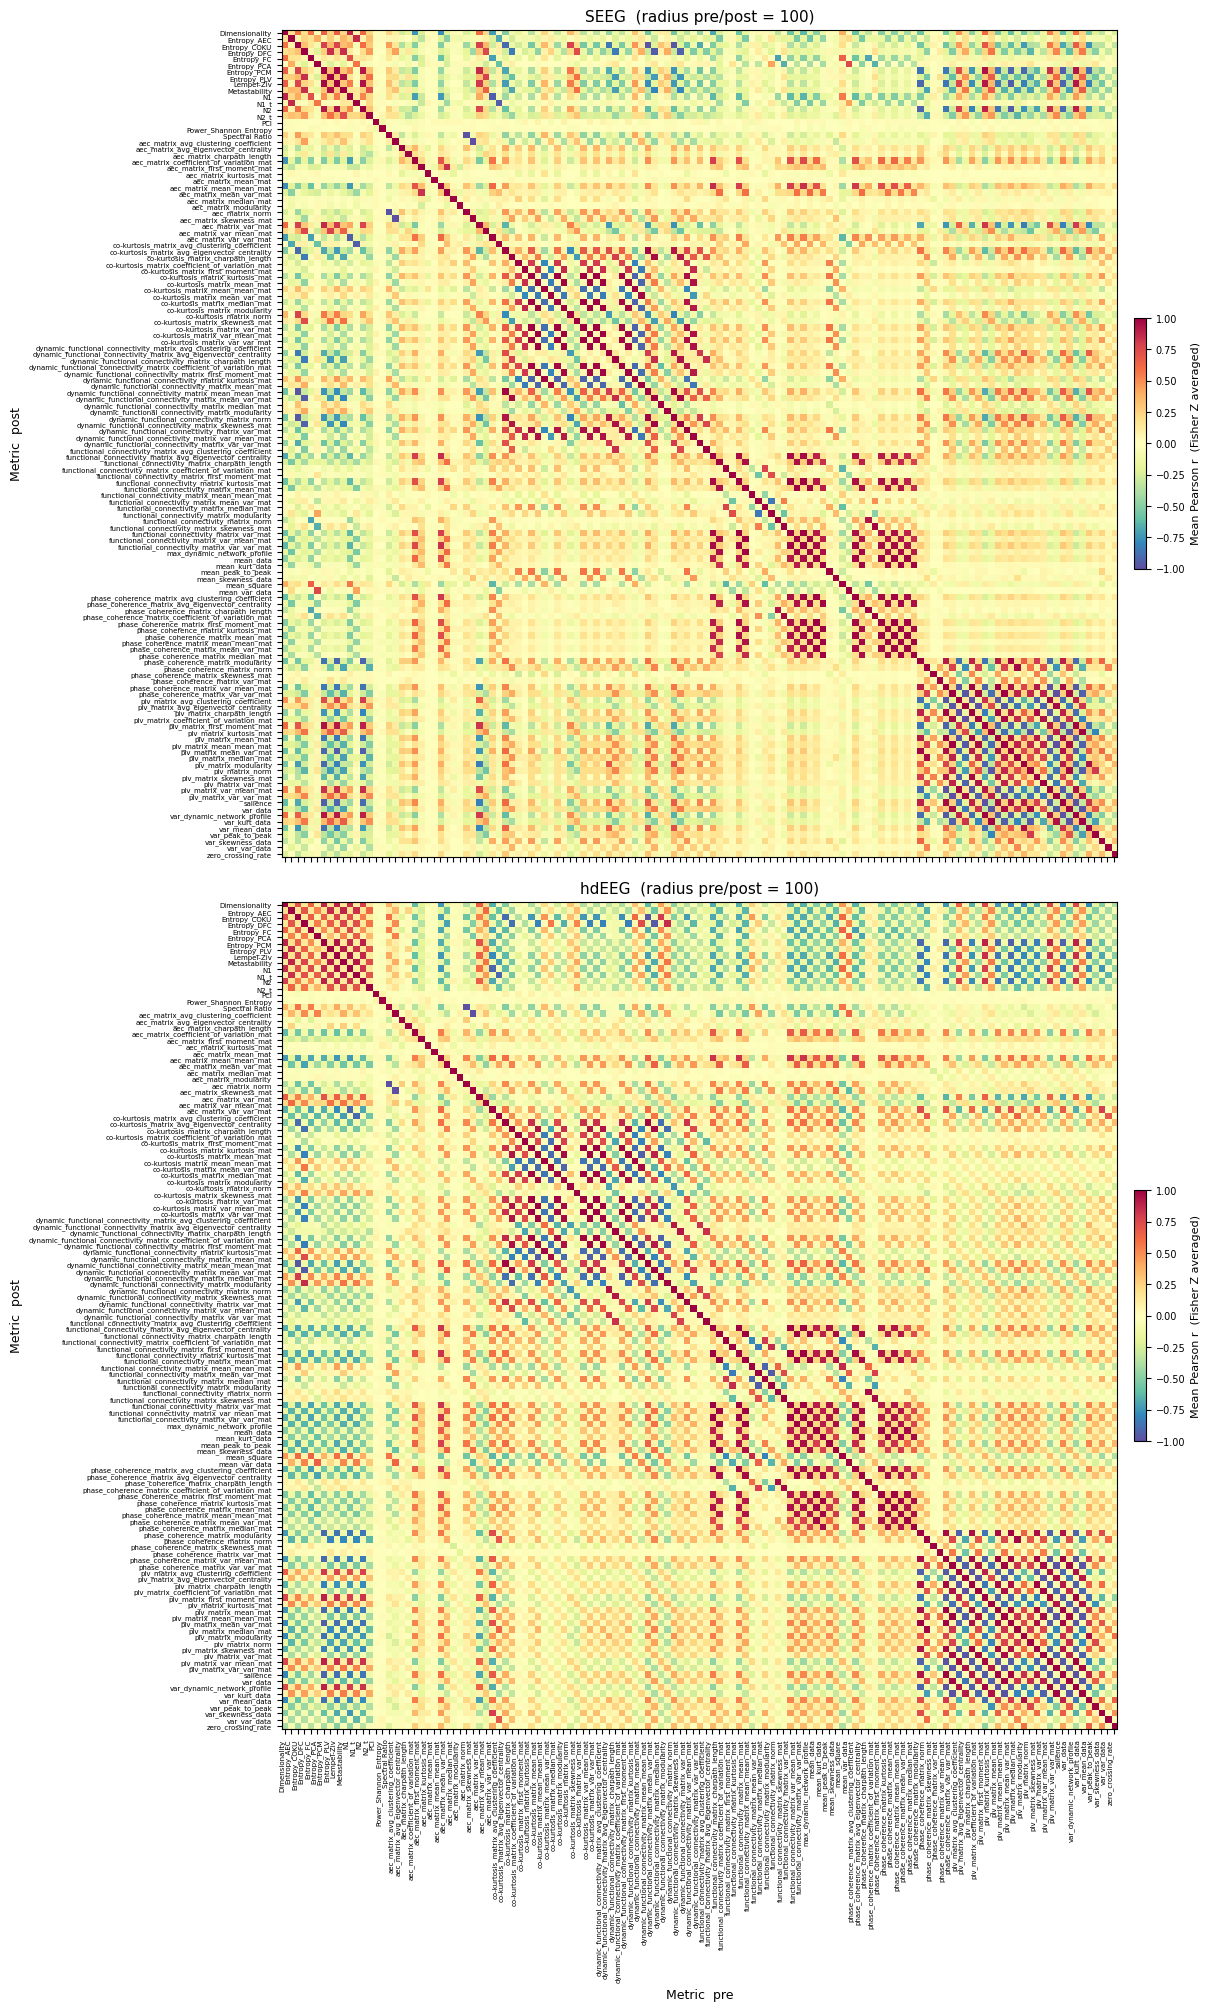

Saved: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/allMOIs_corr_heatmap_100radius.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcdefaults()

CMAP           = 'Spectral_r'
VLIM           = 1.0    # colour scale: –1 to +1
LABEL_FONTSIZE = 5.0


def mean_corr_matrix_fisherz(df: pd.DataFrame) -> pd.DataFrame:
    """Average Pearson correlations using Fisher Z transform, then back-transform.

    r  →  z = arctanh(r)  →  mean(z)  →  r_mean = tanh(mean_z)
    Clips r to (–0.9999, 0.9999) before arctanh to avoid ±inf.
    """
    tmp = df.copy()
    tmp['z'] = np.arctanh(np.clip(tmp['Correlation'], -0.9999, 0.9999))
    mean_z = (
        tmp.groupby(['Metric_pre', 'Metric_post'], sort=True)['z']
        .mean()
        .reset_index()
    )
    mean_z['r_mean'] = np.tanh(mean_z['z'])
    return mean_z.pivot(index='Metric_pre', columns='Metric_post', values='r_mean')


mat_seeg  = mean_corr_matrix_fisherz(outputs['SEEG'])
mat_hdeeg = mean_corr_matrix_fisherz(outputs['hdEEG'])

# Align both matrices to the same sorted metric order
all_metrics = sorted(set(mat_seeg.index) | set(mat_hdeeg.index))
mat_seeg  = mat_seeg.reindex(index=all_metrics, columns=all_metrics)
mat_hdeeg = mat_hdeeg.reindex(index=all_metrics, columns=all_metrics)

# Transpose: rows → Metric_post (y-axis), columns → Metric_pre (x-axis)
mat_seeg  = mat_seeg.T
mat_hdeeg = mat_hdeeg.T

n = len(all_metrics)

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 20),
    constrained_layout=True,
)

for idx, (ax, mat, title) in enumerate(zip(
    axes,
    [mat_seeg, mat_hdeeg],
    ['SEEG  (radius pre/post = 100)', 'hdEEG  (radius pre/post = 100)'],
)):
    im = ax.imshow(
        mat.values,
        cmap=CMAP,
        vmin=-VLIM,
        vmax=VLIM,
        aspect='auto',
        interpolation='nearest',
    )

    ax.set_yticks(range(n))
    ax.set_yticklabels(all_metrics, fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Metric  post', fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)

    cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
    cbar.set_label('Mean Pearson r  (Fisher Z averaged)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    if idx == 0:
        # Top panel: hide x-tick labels (same metric order as bottom)
        ax.set_xticks(range(n))
        ax.set_xticklabels([])
    else:
        # Bottom panel: show x-tick labels
        ax.set_xticks(range(n))
        ax.set_xticklabels(all_metrics, rotation=90, fontsize=LABEL_FONTSIZE, ha='right')
        ax.set_xlabel('Metric  pre', fontsize=9)

figure_dir = project_root / 'results' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)
out_path = figure_dir / 'allMOIs_corr_heatmap_100radius.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')